## 3. Visual Exploratory Data Analysis

We analyze the trends, distributions, and depth of the 100m over the past 50 years.

In [1]:
plt.figure(figsize=(15, 30))

# Plot 1: Time Series Trend
plt.subplot(6, 1, 1)
sns.lineplot(data=stats_df, x='year', y='best', label='Yearly Best', color='red', marker='o')
sns.lineplot(data=stats_df, x='year', y='top_10_avg', label='Top 10 Average', color='blue', linestyle='--')
plt.title("100m: Historical Performance Trend (1974-2024)")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")

# Plot 2: Decadal Boxplot
plt.subplot(6, 1, 2)
clean_df['decade'] = (clean_df['year'] // 10) * 10
sns.boxplot(data=clean_df, x='decade', y='seconds')
plt.title("100m: Distribution of Marks by Decade")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")

# Plot 3: Summary Statistics (Mean vs Median)
plt.subplot(6, 1, 3)
plt.plot(stats_df['year'], stats_df['median'], label='Median', color='orange')
plt.plot(stats_df['year'], stats_df['top_10_avg'], label='Top 10 Avg', color='blue')
plt.title("100m: Median vs Top 10 Average")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")
plt.legend()

# Plot 4: Performance Depth (Gap between Rank 1 and 50)
plt.subplot(6, 1, 4)
depth = clean_df.groupby('year').apply(lambda x: x['seconds'].nsmallest(min(50, len(x))).max() - x['seconds'].min())
plt.plot(depth.index, depth.values, color='purple', marker='x')
plt.title("100m: Performance Depth (Gap between Rank 1 and Rank 50)")
plt.ylabel("Seconds Gap")

# Plot 5: Correlation Heatmap
plt.subplot(6, 1, 5)
sns.heatmap(stats_df[['best', 'top_10_avg', 'median', 'count']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation of Yearly Metrics")

# Plot 6: Cumulative Improvement
plt.subplot(6, 1, 6)
improv = (stats_df['best'].iloc[0] - stats_df['best']) / stats_df['best'].iloc[0] * 100
plt.fill_between(stats_df['year'], improv, color='green', alpha=0.3)
plt.plot(stats_df['year'], improv, color='green')
plt.title("100m: Cumulative Improvement % since 1974")
plt.ylabel("% Improved")

plt.tight_layout()
plt.show()

# Plot 7: Wind Impact (Sprint specific)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_df[clean_df['wind'] != '0.0'], x='wind', y='seconds', alpha=0.3)
plt.title("100m: Impact of Wind on Performance")
plt.gca().invert_yaxis()
plt.show()

NameError: name 'plt' is not defined

# Trackflation: Historical Analysis and Projections

This notebook analyzes 50 years of track and field data to identify performance trends and project future world records.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../'))

from src.data_cleaner import DataCleaner
from src.analysis_engine import AnalysisEngine
from src.forecaster import TrackForecaster

sns.set_theme(style="whitegrid")

C:\Users\thoma\Downloads\trackflation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing plotly failed. Interactive plots will not work.


## 1. Data Generation (Simulated)

Since we haven't scraped the full 50 years yet, we generate a synthetic dataset with a realistic improvement trend for the 100m sprint.

In [3]:
start_year = 1974
end_year = 2024
years = list(range(start_year, end_year + 1))
data = []
base_time = 10.3

np.random.seed(42)
for y in years:
    # Annual improvement trend
    year_best = base_time - (y - start_year) * 0.012 + (np.random.random() * 0.08)
    for _ in range(100):
        data.append({
            "year": y,
            "mark": f"{year_best + np.random.random() * 0.4:.2f}",
            "wind": "1.0",
            "athlete": f"Athlete_{np.random.randint(1000)}",
            "date": f"{y}-07-15",
            "event": "100-metres"
        })

df = pd.DataFrame(data)
df.head()

,year,mark,wind,athlete,date,event
0,1974,10.71,1.0,Athlete_106,1974-07-15,100-metres
1,1974,10.64,1.0,Athlete_20,1974-07-15,100-metres
2,1974,10.39,1.0,Athlete_466,1974-07-15,100-metres
3,1974,10.37,1.0,Athlete_458,1974-07-15,100-metres
4,1974,10.68,1.0,Athlete_99,1974-07-15,100-metres


## 2. Cleaning and Statistical Analysis

In [4]:
cleaner = DataCleaner()
clean_df = cleaner.clean_scraped_data(df)

engine = AnalysisEngine(clean_df)
stats_df = engine.get_yearly_stats()
stats_df.tail()

,year,best,top_10_avg,median,count
46,2020,9.78,9.793,9.995,100
47,2021,9.79,9.809,9.970,100
48,2022,9.80,9.824,9.990,100
49,2023,9.76,9.789,9.990,100
50,2024,9.77,9.789,9.965,100


## 3. Visual Exploratory Data Analysis

We analyze the trends, distributions, and depth of the 100m over the past 50 years.

C:\Users\thoma\AppData\Local\Temp\ipykernel_16468\1260694600.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depth = clean_df.groupby('year').apply(lambda x: x['seconds'].nsmallest(min(50, len(x))).max() - x['seconds'].min())


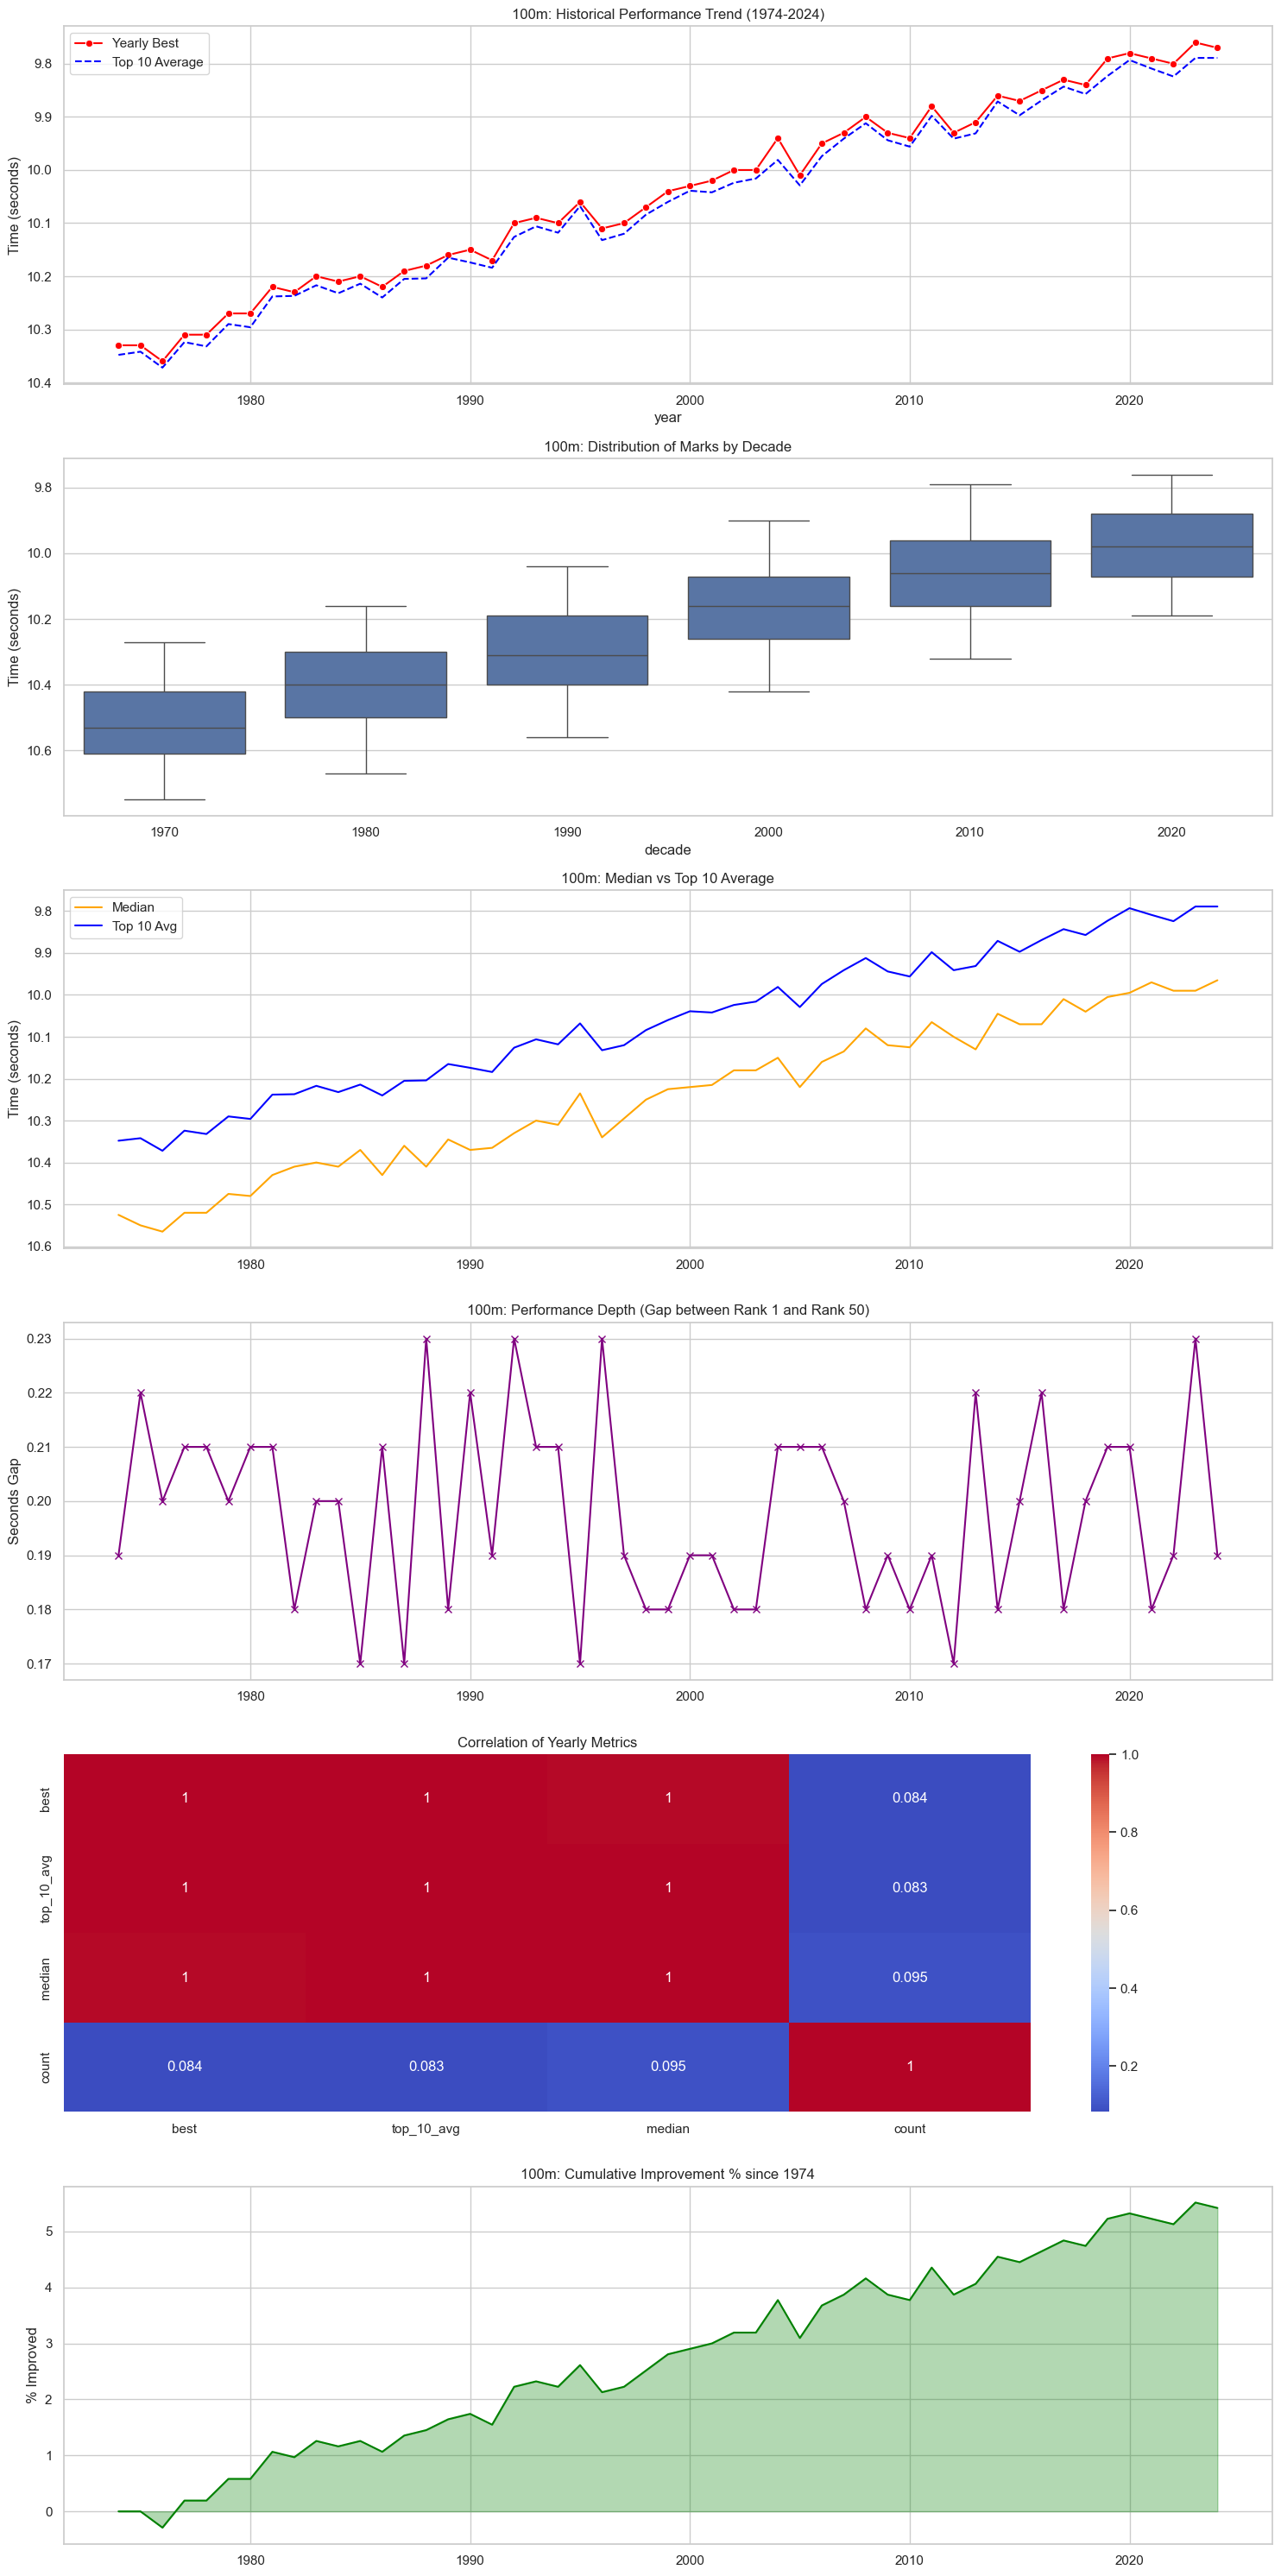

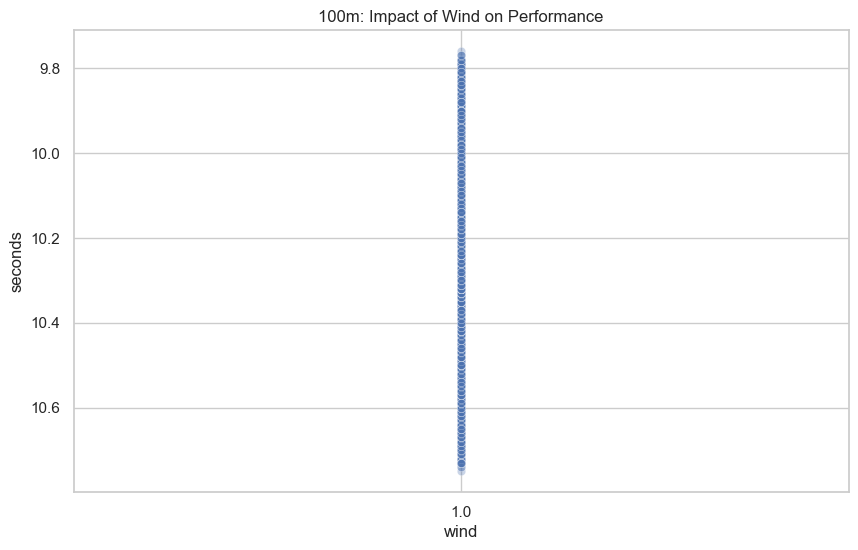

In [5]:
plt.figure(figsize=(15, 30))

# Plot 1: Time Series Trend
plt.subplot(6, 1, 1)
sns.lineplot(data=stats_df, x='year', y='best', label='Yearly Best', color='red', marker='o')
sns.lineplot(data=stats_df, x='year', y='top_10_avg', label='Top 10 Average', color='blue', linestyle='--')
plt.title("100m: Historical Performance Trend (1974-2024)")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")

# Plot 2: Decadal Boxplot
plt.subplot(6, 1, 2)
clean_df['decade'] = (clean_df['year'] // 10) * 10
sns.boxplot(data=clean_df, x='decade', y='seconds')
plt.title("100m: Distribution of Marks by Decade")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")

# Plot 3: Summary Statistics (Mean vs Median)
plt.subplot(6, 1, 3)
plt.plot(stats_df['year'], stats_df['median'], label='Median', color='orange')
plt.plot(stats_df['year'], stats_df['top_10_avg'], label='Top 10 Avg', color='blue')
plt.title("100m: Median vs Top 10 Average")
plt.gca().invert_yaxis()
plt.ylabel("Time (seconds)")
plt.legend()

# Plot 4: Performance Depth (Gap between Rank 1 and 50)
plt.subplot(6, 1, 4)
depth = clean_df.groupby('year').apply(lambda x: x['seconds'].nsmallest(min(50, len(x))).max() - x['seconds'].min())
plt.plot(depth.index, depth.values, color='purple', marker='x')
plt.title("100m: Performance Depth (Gap between Rank 1 and Rank 50)")
plt.ylabel("Seconds Gap")

# Plot 5: Correlation Heatmap
plt.subplot(6, 1, 5)
sns.heatmap(stats_df[['best', 'top_10_avg', 'median', 'count']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation of Yearly Metrics")

# Plot 6: Cumulative Improvement
plt.subplot(6, 1, 6)
improv = (stats_df['best'].iloc[0] - stats_df['best']) / stats_df['best'].iloc[0] * 100
plt.fill_between(stats_df['year'], improv, color='green', alpha=0.3)
plt.plot(stats_df['year'], improv, color='green')
plt.title("100m: Cumulative Improvement % since 1974")
plt.ylabel("% Improved")

plt.tight_layout()
plt.show()

# Plot 7: Wind Impact (Sprint specific)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_df[clean_df['wind'] != '0.0'], x='wind', y='seconds', alpha=0.3)
plt.title("100m: Impact of Wind on Performance")
plt.gca().invert_yaxis()
plt.show()

## 4. Performance Projections (Next 20 Years)

Using the Prophet model with **Logistic Growth** and **Rolling Window Conformal Prediction** to forecast where the 100m World Record might be in 2046.

21:14:30 - cmdstanpy - INFO - Chain [1] start processing


21:14:31 - cmdstanpy - INFO - Chain [1] done processing


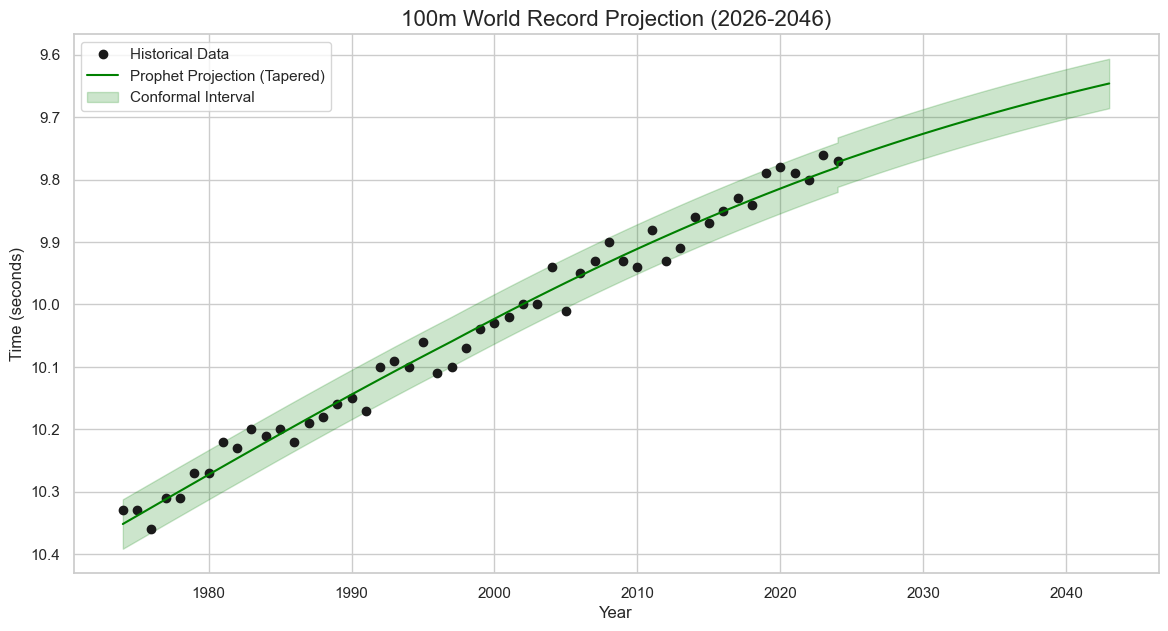

Projected 100m WR in 2046: 9.65


In [6]:
forecaster = TrackForecaster(stats_df, cap=9.45)
forecast = forecaster.forecast(periods=20)

plt.figure(figsize=(14, 7))
plt.plot(stats_df['year'], stats_df['best'], 'ko', label='Historical Data')
plt.plot(pd.to_datetime(forecast['ds']).dt.year, forecast['yhat'], color='green', label='Prophet Projection (Tapered)')
plt.fill_between(pd.to_datetime(forecast['ds']).dt.year, forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2, label='Conformal Interval')

plt.title("100m World Record Projection (2026-2046)", fontsize=16)
plt.ylabel('Time (seconds)')
plt.xlabel('Year')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

proj_2046 = forecast.iloc[-1]['yhat']
print(f"Projected 100m WR in 2046: {forecaster.seconds_to_str(proj_2046)}")